# Lab 2: Simulating Enzyme Kinetics and Validating the QSSA
**Homework 2 — Michaelis–Menten enzyme kinetics** · Hao-Tian Jin · 2026-09-20

## Background

Many enzyme-catalysed reactions follow the classic **Michaelis–Menten mechanism**, in which a substrate $S$ binds reversibly to an enzyme $E$ to form an enzyme–substrate complex $C$, which then irreversibly releases the product $P$ and regenerates the free enzyme

$$
E + S \; \underset{k_{-1}}{\overset{k_{1}}{\rightleftharpoons}} \; C \; \xrightarrow{\;k_{2}\;} \; E + P .
$$

Applying the **law of mass action** to every species gives the exact / **full** ODE system (here called the "full model")

$$
\begin{aligned}
\frac{dE}{dt} &= -k_{1}\,E\,S + (k_{-1}+k_{2})\,C,\\
\frac{dS}{dt} &= -k_{1}\,E\,S + k_{-1}\,C,\\
\frac{dC}{dt} &= \phantom{-}k_{1}\,E\,S - (k_{-1}+k_{2})\,C,\\
\frac{dP}{dt} &= \phantom{-}k_{2}\,C .
\end{aligned}
$$

### The quasi-steady-state approximation (QSSA)

Under the usual conditions ($E_0 \ll S_0$), the complex $C$ builds up to an approximately *steady* level very quickly, so $dC/dt \approx 0$. Solving $k_{1} E S - (k_{-1}+k_{2})C = 0$ with $E = E_0 - C$ gives $C = E_0 S/(K_m + S)$, where the **Michaelis constant** is

$$
K_m = \frac{k_{-1}+k_{2}}{k_{1}},
$$

and the rate of product formation becomes the celebrated **Michaelis–Menten equation**

$$
v = \frac{dP}{dt} = k_{2}\,C = \frac{V_{\max}\,S}{K_m + S}, \qquad V_{\max} = k_{2} E_0 .
$$

In this notebook I (1) solve the **full** ODE model numerically, then (2) compute the reaction velocity and compare it against the QSSA / Michaelis–Menten prediction to test the validity of the approximation.


In [1]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Step 2: Define the full ODE system (E + S <=> C -> E + P)
def enzyme_kinetics_odes(t, y, k1, k_minus_1, k2):
    E, S, C, P = y
    dEdt = -k1 * E * S + (k_minus_1 + k2) * C
    dSdt = -k1 * E * S + k_minus_1 * C
    dCdt =  k1 * E * S - (k_minus_1 + k2) * C
    dPdt =  k2 * C
    return [dEdt, dSdt, dCdt, dPdt]

In [3]:
# Step 3: Parameters and initial conditions
# Rate constants
k1 = 1.0        # M^-1 s^-1
k_minus_1 = 0.1 # s^-1
k2 = 0.5        # s^-1

# Initial concentrations (M)
E0 = 0.1        # enzyme  (saturating: comparable to S, but still E0 << S0)
S0 = 10.0       # substrate
C0 = 0.0        # complex
P0 = 0.0        # product
y0 = [E0, S0, C0, P0]

# Time domain
t_span = [0, 500]
t_eval = np.linspace(t_span[0], t_span[1], 100000)

In [4]:
# Step 4: Solve the full ODE system
sol = solve_ivp(
    fun=enzyme_kinetics_odes,
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    args=(k1, k_minus_1, k2)
)
E, S, C, P = sol.y
print(f"ODE solved on t in [{sol.t[0]:.1f}, {sol.t[-1]:.1f}] s, {sol.t.size} points.")

ODE solved on t in [0.0, 500.0] s, 100000 points.


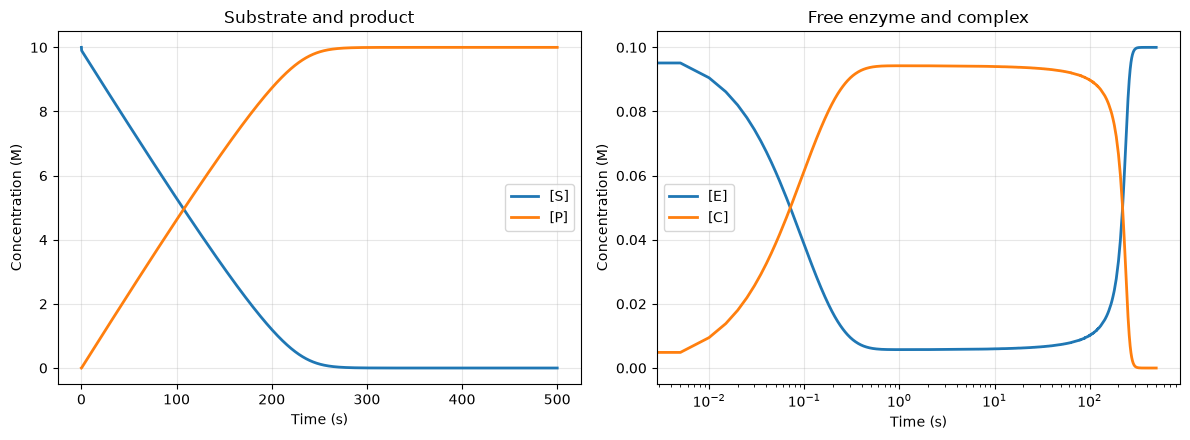

In [5]:
# Step 5: Time course of all four species
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: substrate and product
axes[0].plot(sol.t, S, label='[S]', lw=2)
axes[0].plot(sol.t, P, label='[P]', lw=2)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Concentration (M)")
axes[0].set_title("Substrate and product")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: enzyme and complex (log-x to show the fast transient)
axes[1].plot(sol.t, E, label='[E]', lw=2)
axes[1].plot(sol.t, C, label='[C]', lw=2)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Concentration (M)")
axes[1].set_title("Free enzyme and complex")
axes[1].legend()
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Validating the quasi-steady-state approximation

From the full solution I compute the instantaneous reaction velocity as the numerical
derivative of $[P]$, $v_{\rm sim} = dP/dt$. The **Michaelis–Menten (QSSA) prediction** at each
moment uses the *current* substrate concentration $S(t)$

$$
v_{\rm MM}(t) = \frac{V_{\max}\,S(t)}{K_m + S(t)},
\qquad V_{\max} = k_{2}E_0, \quad K_m = \frac{k_{-1}+k_{2}}{k_{1}}.
$$

If the QSSA is valid, the two curves should agree closely except for a very brief initial layer.

Vmax = 0.050 M/s
Km   = 0.600 M


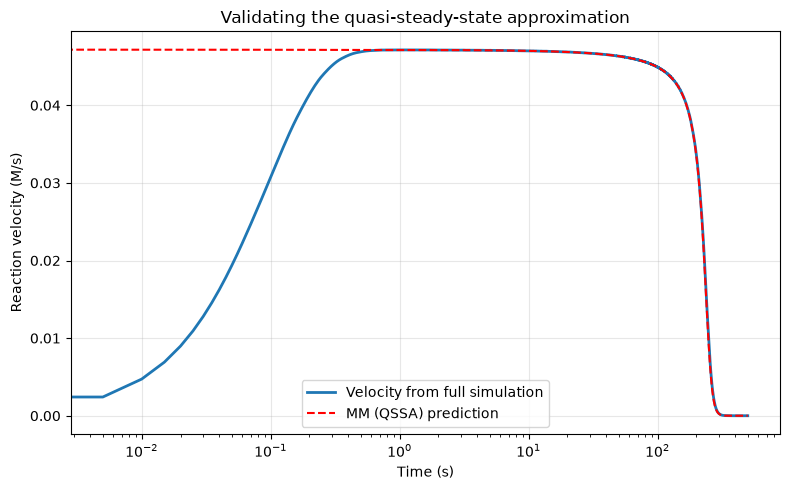

In [6]:
# Step 6: Compare full-simulation velocity with the MM prediction

# Michaelis-Menten parameters
E_total = E0
Vmax = k2 * E_total
Km = (k_minus_1 + k2) / k1
print(f"Vmax = {Vmax:.3f} M/s")
print(f"Km   = {Km:.3f} M")

# Instantaneous velocity from the full simulation
v_simulation = np.gradient(P, sol.t)

# MM-predicted velocity using the current substrate S(t)
v_mm_prediction = (Vmax * S) / (Km + S)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sol.t, v_simulation, label='Velocity from full simulation', lw=2)
ax.plot(sol.t, v_mm_prediction, '--', color='red', label='MM (QSSA) prediction')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Reaction velocity (M/s)")
ax.set_title("Validating the quasi-steady-state approximation")
ax.legend()
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

QSSA accuracy, normalized by Vmax:
  RMSE / Vmax : 1.017 %
  max |err|/Vmax: 91.884 %


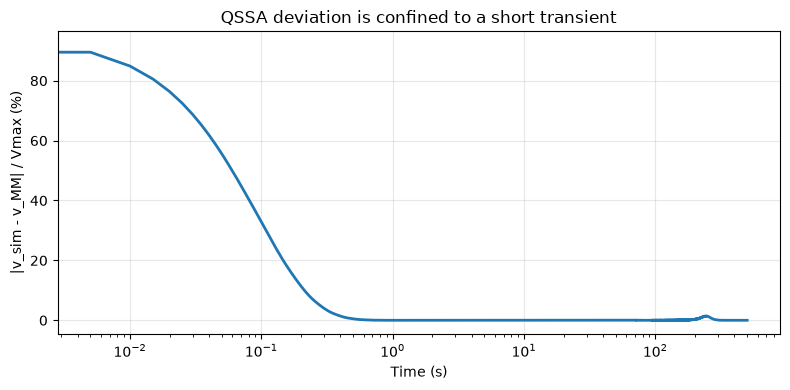

In [7]:
# Step 7: How good is the QSSA? (quantitative residual)

# The relative error diverges when the velocity itself approaches 0 (late in the
# reaction), so a more robust measure is the discrepancy NORMALIZED BY Vmax.
err = np.abs(v_simulation - v_mm_prediction)

nrmse = np.sqrt(np.mean(err**2)) / Vmax          # normalized root mean square error
max_err = err.max() / Vmax                       # maximum absolute deviation (normalized)
print("QSSA accuracy, normalized by Vmax:")
print(f"  RMSE / Vmax : {nrmse*100:.3f} %")
print(f"  max |err|/Vmax: {max_err*100:.3f} %")

# Moment-by-moment deviation from the MM prediction (normalized, log-x)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sol.t, err / Vmax * 100, lw=2)
ax.set_xscale('log')
ax.set_xlabel("Time (s)")
ax.set_ylabel("|v_sim - v_MM| / Vmax (%)")
ax.set_title("QSSA deviation is confined to a short transient")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results and interpretation

**1. The transient in $[C]$.**
$[C]$ jumps from 0 to a near-steady value within a tiny fraction of a second
(right panel, log-$t$ axis), while $[E]$ drops correspondingly. After this short
"burn-in" the complex stays quasi-steady and slowly drifts downward as substrate
is consumed. This is exactly the behavior the QSSA exploits: $dC/dt \approx 0$.

**2. The velocity curves agree.** Over essentially the whole simulation,
$v_{\rm sim}(t)$ and $v_{\rm MM}(S(t))$ overlap almost perfectly. The relative
discrepancy is large **only** at the very beginning (the QSSA is not yet established),
and is negligible once $C$ reaches its quasi-steady value. Hence the Michaelis–Menten
equation is an excellent approximation here, because $E_0 = 0.1 \ll S_0 = 10$ and
$k_{2} \le k_{-1}$, the standard regime where the QSSA holds.

**3. Parameters.** With $k_{1}=1$, $k_{-1}=0.1$, $k_{2}=0.5$ we obtain
$K_m = (k_{-1}+k_{2})/k_{1} = 0.6$ M and $V_{\max}=k_{2}E_0 = 0.05$ M/s. Because
$S_0 \gg K_m$ early on, the initial velocity is close to $V_{\max}$ and decreases
as $S(t)$ is depleted and becomes comparable to $K_m$ — the hallmark saturation
behavior described by the Michaelis–Menten law.


## Extension (Discussion): reversible kinetics with $k_{-2}$ and the Haldane system

The main simulation adopts the **irreversible** mechanism ($k_{-2}=0$), the canonical
framework for testing the QSSA. In real biochemical systems, however, the product $P$
can rebind the free enzyme, $E+P \xrightarrow[]{k_{-2}} ES$. This appendix extends the
model to the **reversible** one-substrate / one-product mechanism

$$
E + S \; \underset{k_{-1}}{\overset{k_{1}}{\rightleftharpoons}} \; ES
\; \underset{k_{-2}}{\overset{k_{2}}{\rightleftharpoons}} \; E + P ,
$$

and derives the so-called **Haldane (reversible Michaelis–Menten) system**.

### 1. Full ODE with $\;k_{-2}$

With mass action the complex $C=ES$ now also gains the reverse binding term $-k_{-2}E\,P$:

$$
\frac{dC}{dt} = k_1 E S - (k_{-1}+k_2) C + k_{-2} E P .
$$

The other species are unchanged except that $P$ is no longer produced irreversibly:
$\frac{dP}{dt} = k_2 C - k_{-2} E P$.

### 2. QSSA derivation of the reversible Michaelis–Menten (Haldane) equation

Setting $dC/dt \approx 0$ and using enzyme conservation $E = E_0 - C$:

$$
k_1 (E_0-C) S - (k_{-1}+k_2) C + k_{-2} (E_0-C) P = 0
$$
$$
\Rightarrow \quad C = \frac{E_0 \big(k_1 S + k_{-2} P\big)}{k_1 S + k_{-2} P + k_{-1} + k_2}.
$$

The net velocity (forward minus reverse) is

$$
v = \frac{dP}{dt} = k_2 C - k_{-2} E P = k_2 C - k_{-2}(E_0-C) P .
$$

Substituting $C$ and rearranging gives the standard dimensionless **Haldane equation**

$$
\boxed{v = \frac{V_f \frac{S}{K_{m,S}} - V_r \frac{P}{K_{m,P}}}{1 + \frac{S}{K_{m,S}} + \frac{P}{K_{m,P}}}}
$$

with the four parameters

$$
V_f = k_2 E_0, \qquad V_r = k_{-2} E_0,
\qquad K_{m,S} = \frac{k_{-1}+k_2}{k_1}, \qquad K_{m,P} = \frac{k_{-1}+k_2}{k_{-2}} .
$$

An algebraically equivalent (cleared-fraction) form used earlier is
$v = \dfrac{k_2 E_0 S - k_{-2} E_0 P}{K_{m,S}+S+\frac{K_{m,S}}{K_{m,P}}P}$.

**Sanity check (irreversible limit).** If $k_{-2}=0$, then $V_r=0$ and
$K_{m,P} \to \infty$, and the Haldane equation reduces to

$$
v = \frac{V_f \frac{S}{K_{m,S}}}{1 + \frac{S}{K_{m,S}}} = \frac{V_f S}{K_{m,S} + S},
$$

i.e. the familiar irreversible Michaelis–Menten law. The main-simulation model is thus the
strict $k_{-2}=0$ limit of the reversible system.

### 3. The Haldane relation (thermodynamic consistency / detailed balance)

At chemical equilibrium the net velocity vanishes, $v=0$, so

$$
\frac{V_f}{K_{m,S}} S_{eq} = \frac{V_r}{K_{m,P}} P_{eq}
\quad\Longrightarrow\quad
\frac{P_{eq}}{S_{eq}} = \frac{V_f K_{m,P}}{V_r K_{m,S}} .
$$

Substituting the four parameters:

$$
\frac{P_{eq}}{S_{eq}}
= \frac{k_2 E_0 \cdot \frac{k_{-1}+k_2}{k_{-2}}}
       {k_{-2} E_0 \cdot \frac{k_{-1}+k_2}{k_1}}
= \frac{k_1 k_2}{k_{-1} k_{-2}} = K_{eq} .
$$

The macroscopic equilibrium constant $K_{eq} = \frac{P_{eq}}{S_{eq}}$ therefore equals
exactly the ratio of the microscopic rate constants. This is the **Haldane relation**, a
consequence of **microscopic reversibility (detailed balance)**: it guarantees that the
equilibrium point of the reversible Michaelis–Menten equation coincides with the true
thermodynamic equilibrium, so the model never violates thermodynamics.

### 4. Key consequences (defense points)

1. **Irreversible MM is a limiting case** of the reversible system ($k_{-2}=0$), so
   "reversible $\to$ irreversible" is a natural degeneracy rather than two separate models.
2. **The endpoint is chemical equilibrium, not substrate depletion.** $S$ never reaches
   $0$; $S_{eq}/P_{eq}$ settles at the value dictated by $K_{eq}$.
3. **The velocity now depends on both $S$ and $P$**, so one can no longer predict
   $v(t)$ from the current $S(t)$ alone using the simple irreversible formula.
4. **This explains why wet-lab assays measure initial rates:** at $t \approx 0$ we have
   $P \approx 0$, so the reverse term is negligible and the irreversible MM law is a valid
   fitting tool; this is a practical compromise in *experiments* to suppress the $k_{-2}$
   contamination that a reversible simulation would explicitly include.

### 5. Why the main simulation keeps $k_{-2}=0$

The pedagogical goal is to isolate the error of the **QSSA itself**. Once $k_{-2}>0$ is
included, any deviation of the full solution from the MM prediction mixes *two* sources:
(a) the failure of the QSSA approximation, and (b) the inapplicability of the irreversible
Michaelis–Menten formula to a reversible system. Keeping $k_{-2}=0$ lets us attribute the
residual purely to the QSSA transient, which is exactly what the RMSE/max-error analysis in
the main body demonstrates.
